In [1]:
!pip -q install yfinance

In [2]:
import os, math, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/BUSA310/Assignment2'
CODE_DIR = f'{BASE}/Colab_Codes'
RESULTS_DIR = f'{BASE}/Results'
os.makedirs(CODE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

START = '2025-09-06'
END = '2026-09-06'

# Yahoo Finance uses BTC-USD rather than BTCUSD.
tickers_yf = ['SPY','TSLA','GM','BTC-USD','AAPL','JNJ','XOM','EFA']
display_names = {
    'SPY':'SPY',
    'TSLA':'TSLA',
    'GM':'GM',
    'BTC-USD':'BTCUSD',
    'AAPL':'AAPL',
    'JNJ':'JNJ',
    'XOM':'XOM',
    'EFA':'EFA'
}

Mounted at /content/drive


In [3]:
# Section 1 — Data Collection and Organization
end_plus_one = (pd.Timestamp(END) + pd.Timedelta(days=1)).strftime('%Y-%m-%d')

df = yf.download(
    tickers_yf,
    start=START,
    end=end_plus_one,
    auto_adjust=False,
    group_by='column',
    progress=False,
    threads=True
)

print('FIRST 15 ROWS OF RAW DATA')
display(df.head(15))

print('\nRAW DATA INFO')
df.info()

print('\nRAW DATA DESCRIBE')
display(df.describe())

FIRST 15 ROWS OF RAW DATA


Price        Adj Close                                                   \
Ticker            AAPL        BTC-USD        EFA         GM         JNJ   
Date                                                                      
2025-09-06         NaN  110224.695312        NaN        NaN         NaN   
2025-09-07         NaN  111167.617188        NaN        NaN         NaN   
2025-09-08  237.004517  112071.429688  89.641426  57.702179  174.204178   
2025-09-09  233.487518  111530.546875  89.341682  57.513798  173.059982   
2025-09-10  225.955322  113955.359375  89.322342  56.849533  171.915756   
2025-09-11  229.183411  115507.539062  90.269913  58.207813  174.566040   
2025-09-12  233.208542  116101.578125  89.912155  57.999611  174.135712   
2025-09-13         NaN  115950.507812        NaN        NaN         NaN   
2025-09-14         NaN  115407.656250        NaN        NaN         NaN   
2025-09-15  235.828842  115444.875000  90.511635  58.445763  173.490265   
2025-09-16  237.273514  116843.187500  90.260239  57.959953  172.570999   
2025-09-17  238.110428  116468.507812  89.921822  58.227646  173.294678   
2025-09-18  237.004517  117137.203125  90.269913  58.753113  170.321671   
2025-09-19  244.596466  115688.859375  89.921822  58.475506  172.306946   
2025-09-20         NaN  115721.960938        NaN        NaN         NaN   

Price                                                Close                 \
Ticker             SPY        TSLA         XOM        AAPL        BTC-USD   
Date                                                                        
2025-09-06         NaN         NaN         NaN         NaN  110224.695312   
2025-09-07         NaN         NaN         NaN         NaN  111167.617188   
2025-09-08  641.719543  346.399994  106.755920  237.880005  112071.429688   
2025-09-09  643.203125  346.970001  107.533386  234.350006  111530.546875   
2025-09-10  645.062500  347.790009  109.331291  226.789993  113955.359375   
2025-09-11  650.423157  368.809998  108.981430  230.029999  115507.539062   
2025-09-12  650.205505  395.940002  109.000870  234.070007  116101.578125   
2025-09-13         NaN         NaN         NaN         NaN  115950.507812   
2025-09-14         NaN         NaN         NaN         NaN  115407.656250   
2025-09-15  653.667175  410.040009  109.185509  236.699997  115444.875000   
2025-09-16  652.767090  421.619995  111.449890  238.149994  116843.187500   
2025-09-17  651.956116  425.859985  112.042709  238.990005  116468.507812   
2025-09-18  655.002380  416.850006  110.721008  237.880005  117137.203125   
2025-09-19  658.246521  426.070007  109.642273  245.500000  115688.859375   
2025-09-20         NaN         NaN         NaN         NaN  115721.960938   

Price       ...        Open                   Volume                           \
Ticker      ...        TSLA         XOM         AAPL      BTC-USD         EFA   
Date        ...                                                                 
2025-09-06  ...         NaN         NaN          NaN  21500719036         NaN   
2025-09-07  ...         NaN         NaN          NaN  24618007520         NaN   
2025-09-08  ...  354.640015  109.730003   48999500.0  40212813407  12010700.0   
2025-09-09  ...  348.440002  110.529999   66313900.0  45984480722  10893200.0   
2025-09-10  ...  350.549988  111.160004   83440800.0  56377473784  11838300.0   
2025-09-11  ...  350.170013  111.400002   50208600.0  45685065332  11013000.0   
2025-09-12  ...  370.940002  112.860001   55824200.0  54785725894  10010500.0   
2025-09-13  ...         NaN         NaN          NaN  34549454947         NaN   
2025-09-14  ...         NaN         NaN          NaN  32798036057         NaN   
2025-09-15  ...  423.130005  112.180000   42699500.0  52937859416  18108000.0   
2025-09-16  ...  414.500000  112.959999   63421100.0  45781744593  25226900.0   
2025-09-17  ...  415.750000  114.529999   46508000.0  60528025996  17013600.0   
2025-09-18  ...  428.869995  115.169998   44249


RAW DATA INFO
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 366 entries, 2025-09-06 to 2026-09-06
Freq: D
Data columns (total 48 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   (Adj Close, AAPL)     251 non-null    float64
 1   (Adj Close, BTC-USD)  366 non-null    float64
 2   (Adj Close, EFA)      251 non-null    float64
 3   (Adj Close, GM)       251 non-null    float64
 4   (Adj Close, JNJ)      251 non-null    float64
 5   (Adj Close, SPY)      251 non-null    float64
 6   (Adj Close, TSLA)     251 non-null    float64
 7   (Adj Close, XOM)      251 non-null    float64
 8   (Close, AAPL)         251 non-null    float64
 9   (Close, BTC-USD)      366 non-null    float64
 10  (Close, EFA)          251 non-null    float64
 11  (Close, GM)           251 non-null    float64
 12  (Close, JNJ)          251 non-null    float64
 13  (Close, SPY)          251 non-null    float64
 14  (Close, TSLA)         251 non-nu

Price    Adj Close                                                     \
Ticker        AAPL        BTC-USD         EFA          GM         JNJ   
count   251.000000     366.000000  251.000000  251.000000  251.000000   
mean    277.709483   82070.202517   98.417189   75.990014  223.038318   
std      25.305851   17461.445324    5.795221    8.516238   27.838814   
min     225.955322   58558.859375   88.220078   54.876556  170.321671   
25%     258.418808   66937.707031   92.513119   72.452797  201.813942   
50%     271.620667   77575.593750   99.387245   77.689339  227.414093   
75%     298.282745   91302.384766  103.143948   81.848335  241.000809   
max     339.786926  124752.531250  108.809998   90.113647  278.429993   

Price                                            Close                 ...  \
Ticker         SPY        TSLA         XOM        AAPL        BTC-USD  ...   
count   251.000000  251.000000  251.000000  251.000000     366.000000  ...   
mean    700.266892  405.593585  136.551544  278.238207   82070.202517  ...   
std      39.592146   39.954985   18.888435   25.098550   17461.445324  ...   
min     630.346069  298.320007  106.755920  226.789993   58558.859375  ...   
25%     668.202393  381.055008  115.233345  258.970001   66937.707031  ...   
50%     685.656189  409.989990  144.156555  272.190002   77575.593750  ...   
75%     739.217651  435.370010  151.610237  298.539993   91302.384766  ...   
max     777.880005  489.880005  169.218292  340.079987  124752.531250  ...   

Price         Open                    Volume                              \
Ticker        TSLA         XOM          AAPL       BTC-USD           EFA   
count   251.000000  251.000000  2.510000e+02  3.660000e+02  2.510000e+02   
mean    405.550359  138.364542  4.954511e+07  4.305744e+10  1.681267e+07   
std      40.290160   18.238342  2.266930e+07  2.233589e+10  7.789815e+06   
min     302.700012  109.730003  1.791060e+07  9.078987e+09  5.219100e+06   
25%     379.964996  117.389999  3.844545e+07  2.669389e+10  1.101090e+07   
50%     409.910004  145.279999  4.501830e+07  3.917979e+10  1.530050e+07   
75%     436.605011  153.125000  5.251820e+07  5.391031e+10  2.004240e+07   
max     489.880005  172.669998  2.617755e+08  1.531250e+11  5.256730e+07   

Price                                                                         
Ticker            GM           JNJ           SPY          TSLA           XOM  
count   2.510000e+02  2.510000e+02  2.510000e+02  2.510000e+02  2.510000e+02  
mean    8.084824e+06  8.273822e+06  6.917403e+07  6.391712e+07  1.753756e+07  
std     3.839745e+06  2.861878e+06  2.568385e+07  2.466206e+07  6.673032e+06  
min     2.370100e+06  2.316700e+06  2.742230e+07  2.334520e+07  6.137400e+06  
25%     5.873700e+06  6.726150e+06  4.758305e+07  4.630265e+07  1.366790e+07  
50%     7.592500e+06  7.732000e+06  6.518570e+07  6.000490e+07  1.580850e+07  
75%     9.261000e+06  8.965700e+06  8.566420e+07  7.537160e+07  1.936970e+07  
max     4.370650e+07  2.562100e+07  1.652935e+08  1.681564e+08  5.394210e+07  

[8 rows x 48 columns]

In [4]:
# Extract closing prices robustly.
if isinstance(df.columns, pd.MultiIndex):
    lvl0 = df.columns.get_level_values(0)
    price_field = 'Adj Close' if 'Adj Close' in lvl0 else 'Close'
    df_close_raw = df[price_field].copy()
else:
    # Fallback if yfinance returns a single-level DataFrame
    price_field = 'Adj Close' if 'Adj Close' in df.columns else 'Close'
    df_close_raw = df[[price_field]].copy()

df_close_raw = df_close_raw.rename(columns=display_names)

# Count available observations BEFORE aligning calendars.
raw_counts = df_close_raw.notna().sum().sort_values(ascending=False)
print('Available observations before alignment:')
display(raw_counts.to_frame('non_missing_days'))

# For cross-asset comparisons, use only dates on which every asset has a price.
# This avoids forward-filling equity prices over weekends and creating artificial 0% returns.
df_close = df_close_raw.dropna(how='any').copy()

print(f'\nAligned df_close shape: {df_close.shape}')
display(df_close.head())

print('\ndf_close.dtypes')
display(df_close.dtypes)

Available observations before alignment:


,non_missing_days
Ticker,
BTCUSD,366
AAPL,251
EFA,251
GM,251
JNJ,251
SPY,251
TSLA,251
XOM,251



Aligned df_close shape: (251, 8)


Ticker,AAPL,BTCUSD,EFA,GM,JNJ,SPY,TSLA,XOM
Date,,,,,,,,
2025-09-08,237.004517,112071.429688,89.641426,57.702179,174.204178,641.719543,346.399994,106.755920
2025-09-09,233.487518,111530.546875,89.341682,57.513798,173.059982,643.203125,346.970001,107.533386
2025-09-10,225.955322,113955.359375,89.322342,56.849533,171.915756,645.062500,347.790009,109.331291
2025-09-11,229.183411,115507.539062,90.269913,58.207813,174.566040,650.423157,368.809998,108.981430
2025-09-12,233.208542,116101.578125,89.912155,57.999611,174.135712,650.205505,395.940002,109.000870



df_close.dtypes


,0
Ticker,
AAPL,float64
BTCUSD,float64
EFA,float64
GM,float64
JNJ,float64
SPY,float64
TSLA,float64
XOM,float64


In [5]:
# Section 2 — Descriptive Statistics and Risk Metrics

stats_table = pd.DataFrame({
    'Min': df_close.min(),
    'Max': df_close.max(),
    'Mean': df_close.mean(),
    'Std': df_close.std()
}).round(2)

print('PRICE DESCRIPTIVE STATISTICS')
display(stats_table)

# Annual return using the assignment formula
annual_return = (df_close.iloc[-1] - df_close.iloc[0]) / df_close.iloc[0]
annual_return_pct = (annual_return * 100).round(2)

print('ANNUAL RETURN (%)')
display(annual_return_pct.sort_values(ascending=False).to_frame('Annual Return %'))

# Daily returns
daily_returns = df_close.pct_change(fill_method=None).dropna()

# Sharpe
rf_daily = 0.045 / 252
sharpe = ((daily_returns.mean() - rf_daily) / daily_returns.std()) * np.sqrt(252)
sharpe = sharpe.sort_values(ascending=False)

print('ANNUALIZED SHARPE RATIO')
display(sharpe.round(3).to_frame('Sharpe'))

# 30-day rolling std of DAILY returns, shown as %
rolling_30 = daily_returns.rolling(30).std() * 100
print('LAST 10 ROWS: 30-DAY ROLLING DAILY-RETURN STD (%)')
display(rolling_30.tail(10).round(3))

# Required price-level correlation
price_corr = df_close.corr().round(2)
print('PRICE-LEVEL CORRELATION MATRIX')
display(price_corr)

PRICE DESCRIPTIVE STATISTICS


,Min,Max,Mean,Std
Ticker,,,,
AAPL,225.96,339.79,277.71,25.31
BTCUSD,58558.86,124752.53,82202.36,17614.71
EFA,88.22,108.81,98.42,5.80
GM,54.88,90.11,75.99,8.52
JNJ,170.32,278.43,223.04,27.84
SPY,630.35,777.88,700.27,39.59
TSLA,298.32,489.88,405.59,39.95
XOM,106.76,169.22,136.55,18.89


ANNUAL RETURN (%)


,Annual Return %
Ticker,
JNJ,57.99
GM,52.09
XOM,49.38
AAPL,35.01
EFA,20.87
SPY,20.02
TSLA,2.22
BTCUSD,-28.91


ANNUALIZED SHARPE RATIO


,Sharpe
Ticker,
JNJ,2.277
XOM,1.529
GM,1.272
AAPL,1.152
SPY,1.147
EFA,1.010
TSLA,0.190
BTCUSD,-0.664


LAST 10 ROWS: 30-DAY ROLLING DAILY-RETURN STD (%)


Ticker,AAPL,BTCUSD,EFA,GM,JNJ,SPY,TSLA,XOM
Date,,,,,,,,
2026-08-24,2.042,2.428,0.825,2.101,1.465,0.778,3.562,1.406
2026-08-25,2.038,2.344,0.826,2.126,1.429,0.777,3.562,1.480
2026-08-26,1.904,2.336,0.829,2.123,1.344,0.775,3.566,1.514
2026-08-27,1.874,2.306,0.813,2.125,1.376,0.774,3.606,1.531
2026-08-28,1.902,2.407,0.809,2.074,1.369,0.749,3.589,1.526
2026-08-31,1.869,2.393,0.796,2.069,1.337,0.752,3.698,1.589
2026-09-01,1.932,2.410,0.779,1.901,1.373,0.753,3.714,1.588
2026-09-02,1.929,2.404,0.783,1.824,1.354,0.755,3.708,1.566
2026-09-03,1.921,2.509,0.758,1.849,1.347,0.732,2.674,1.565


PRICE-LEVEL CORRELATION MATRIX


Ticker,AAPL,BTCUSD,EFA,GM,JNJ,SPY,TSLA,XOM
Ticker,,,,,,,,
AAPL,1.00,-0.57,0.74,0.61,0.66,0.89,-0.39,0.49
BTCUSD,-0.57,1.00,-0.78,-0.75,-0.88,-0.59,0.53,-0.83
EFA,0.74,-0.78,1.00,0.79,0.89,0.88,-0.55,0.79
GM,0.61,-0.75,0.79,1.00,0.75,0.66,-0.32,0.64
JNJ,0.66,-0.88,0.89,0.75,1.00,0.71,-0.66,0.88
SPY,0.89,-0.59,0.88,0.66,0.71,1.00,-0.42,0.57
TSLA,-0.39,0.53,-0.55,-0.32,-0.66,-0.42,1.00,-0.67
XOM,0.49,-0.83,0.79,0.64,0.88,0.57,-0.67,1.00


In [6]:
# Supporting metrics used for interpretation
ann_vol = daily_returns.std() * np.sqrt(252)
return_corr = daily_returns.corr()

# Utility: unique correlation pairs
def unique_corr_pairs(corr):
    pairs = []
    cols = corr.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            pairs.append((cols[i], cols[j], corr.iloc[i,j]))
    return pd.DataFrame(pairs, columns=['Ticker1','Ticker2','Correlation'])

price_pairs = unique_corr_pairs(df_close.corr())
return_pairs = unique_corr_pairs(return_corr)

highest_price_pair = price_pairs.loc[price_pairs['Correlation'].idxmax()]
lowest_price_pair = price_pairs.loc[price_pairs['Correlation'].idxmin()]
lowest_return_pair = return_pairs.loc[return_pairs['Correlation'].idxmin()]

# Peak rolling volatility date for each ticker
peak_roll = {}
for t in rolling_30.columns:
    s = rolling_30[t].dropna()
    peak_roll[t] = (s.idxmax(), s.max())

print('ANNUALIZED RETURN VOLATILITY (%) — SUPPORTING METRIC')
display((ann_vol*100).round(2).sort_values().to_frame('Annualized return vol %'))

print('\nHighest price-level correlation pair:')
print(highest_price_pair.to_dict())
print('Lowest price-level correlation pair:')
print(lowest_price_pair.to_dict())
print('Lowest RETURN-correlation pair (better diversification evidence):')
print(lowest_return_pair.to_dict())

print('\nPeak 30-day rolling daily-return volatility by ticker:')
for t,(d,v) in peak_roll.items():
    print(f'{t}: {d.date()} — {v:.2f}% daily std')

ANNUALIZED RETURN VOLATILITY (%) — SUPPORTING METRIC


,Annualized return vol %
Ticker,
SPY,12.83
EFA,15.67
JNJ,19.08
AAPL,25.12
XOM,25.69
GM,34.19
BTCUSD,43.96
TSLA,47.47



Highest price-level correlation pair:
{'Ticker1': 'AAPL', 'Ticker2': 'SPY', 'Correlation': 0.8942691008582608}
Lowest price-level correlation pair:
{'Ticker1': 'BTCUSD', 'Ticker2': 'JNJ', 'Correlation': -0.8834096972336338}
Lowest RETURN-correlation pair (better diversification evidence):
{'Ticker1': 'SPY', 'Ticker2': 'XOM', 'Correlation': -0.27682596098335077}

Peak 30-day rolling daily-return volatility by ticker:
AAPL: 2026-08-04 — 2.56% daily std
BTCUSD: 2026-03-16 — 4.73% daily std
EFA: 2026-04-08 — 1.70% daily std
GM: 2025-11-07 — 3.21% daily std
JNJ: 2026-07-30 — 1.94% daily std
SPY: 2026-04-14 — 1.15% daily std
TSLA: 2026-07-23 — 4.28% daily std
XOM: 2026-06-16 — 2.10% daily std


In [14]:
ranking = annual_return_pct.sort_values(ascending=False)
best_ret_ticker = ranking.index[0]
best_ret = ranking.iloc[0]
value_1000 = 1000 * (1 + best_ret/100)

best_sharpe_ticker = sharpe.index[0]
best_sharpe = sharpe.iloc[0]

low_price_std_ticker = stats_table['Std'].idxmin()
low_price_std = stats_table.loc[low_price_std_ticker,'Std']

print('Return ranking:', ' > '.join([f'{t} ({ranking[t]:.2f}%)' for t in ranking.index]))
print(f'Best return: {best_ret_ticker} at {best_ret:.2f}%.')
print(f'$1,000 × (1 + {best_ret:.4f}) = ${value_1000:,.2f}.\n')

print(f'Highest Sharpe: {best_sharpe_ticker} ({best_sharpe:.3f}).')
print(f'Highest annual return: {best_ret_ticker} ({best_ret:.2f}%).')
if best_sharpe_ticker == best_ret_ticker:
    print('They are the same asset in this sample.')
else:
    print('They are different. This shows that the asset with the largest raw gain did not necessarily deliver the best return per unit of volatility. '
          'For comparing investments with different risk, Sharpe is generally more informative than raw return, although it should not be used alone.')

# Choose the ticker with the single highest peak 30-day vol
q7_ticker = max(peak_roll, key=lambda k: peak_roll[k][1])
q7_date, q7_vol = peak_roll[q7_ticker]
print(f'Use {q7_ticker}: peak 30-day daily-return volatility = {q7_vol:.2f}% around {q7_date.date()}.')

print(f'Highest price-level correlation: {highest_price_pair.Ticker1}-{highest_price_pair.Ticker2} = {highest_price_pair.Correlation:.2f}.')
print(f'Lowest price-level correlation: {lowest_price_pair.Ticker1}-{lowest_price_pair.Ticker2} = {lowest_price_pair.Correlation:.2f}.')
print(f'For diversification, I would focus more on return correlations; the lowest return-correlation pair is '
      f'{lowest_return_pair.Ticker1}-{lowest_return_pair.Ticker2} = {lowest_return_pair.Correlation:.2f}. '
    )

print(f'Lowest closing-price standard deviation: {low_price_std_ticker} = {low_price_std:.2f}.')
print(f'Its annual return = {annual_return_pct[low_price_std_ticker]:.2f}% and Sharpe = {sharpe[low_price_std_ticker]:.3f}.')
alt = best_sharpe_ticker
print(f'Compare with {alt}: annual return = {annual_return_pct[alt]:.2f}%, Sharpe = {sharpe[alt]:.3f}, '
      f'annualized return volatility = {ann_vol[alt]*100:.2f}%.')

Return ranking: JNJ (57.99%) > GM (52.09%) > XOM (49.38%) > AAPL (35.01%) > EFA (20.87%) > SPY (20.02%) > TSLA (2.22%) > BTCUSD (-28.91%)
Best return: JNJ at 57.99%.
$1,000 × (1 + 57.9900) = $1,579.90.

Highest Sharpe: JNJ (2.277).
Highest annual return: JNJ (57.99%).
They are the same asset in this sample.
Use BTCUSD: peak 30-day daily-return volatility = 4.73% around 2026-03-16.
Highest price-level correlation: AAPL-SPY = 0.89.
Lowest price-level correlation: BTCUSD-JNJ = -0.88.
For diversification, I would focus more on return correlations; the lowest return-correlation pair is SPY-XOM = -0.28. 
Lowest closing-price standard deviation: EFA = 5.80.
Its annual return = 20.87% and Sharpe = 1.010.
Compare with JNJ: annual return = 57.99%, Sharpe = 2.277, annualized return volatility = 19.08%.


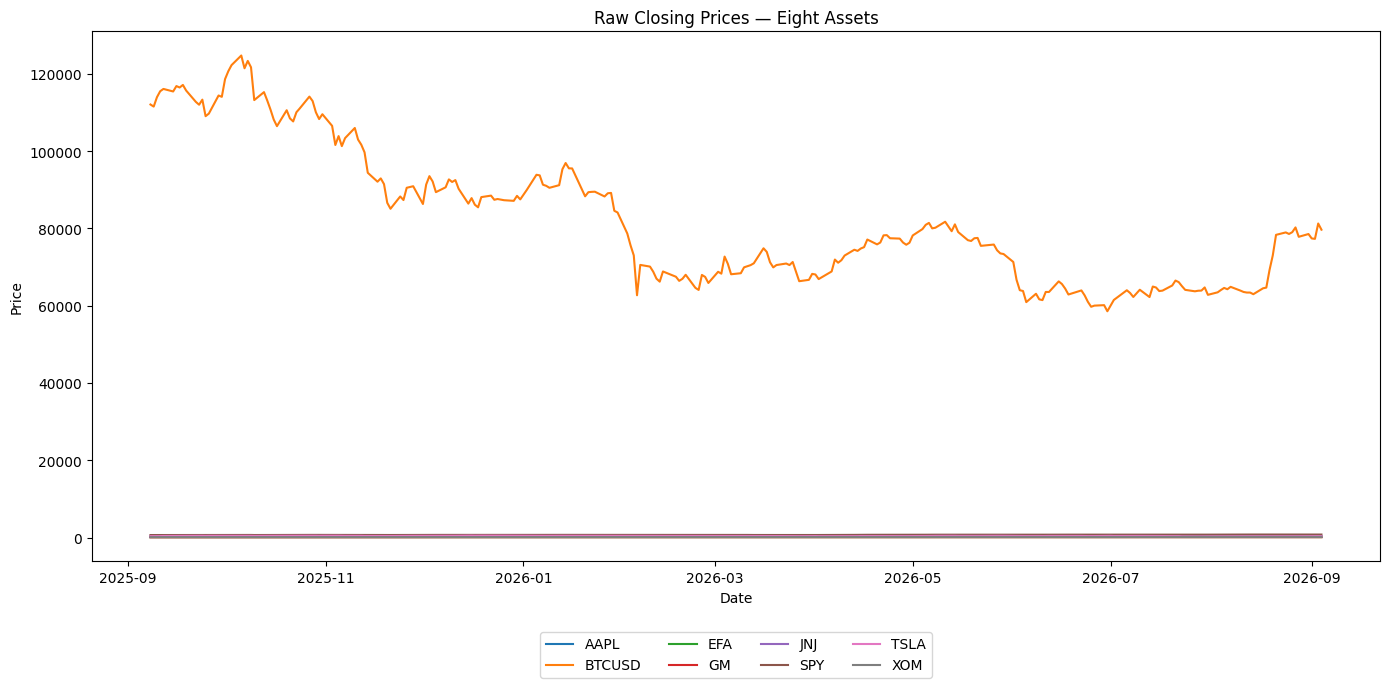

In [9]:
# Section 3 — Visualization

# Part A: Raw price chart
plt.figure(figsize=(14,7))
for c in df_close.columns:
    plt.plot(df_close.index, df_close[c], label=c)
plt.title('Raw Closing Prices — Eight Assets')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(loc='upper center', bbox_to_anchor=(0.5,-0.12), ncol=4)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/raw_prices.png', dpi=200, bbox_inches='tight')
plt.show()

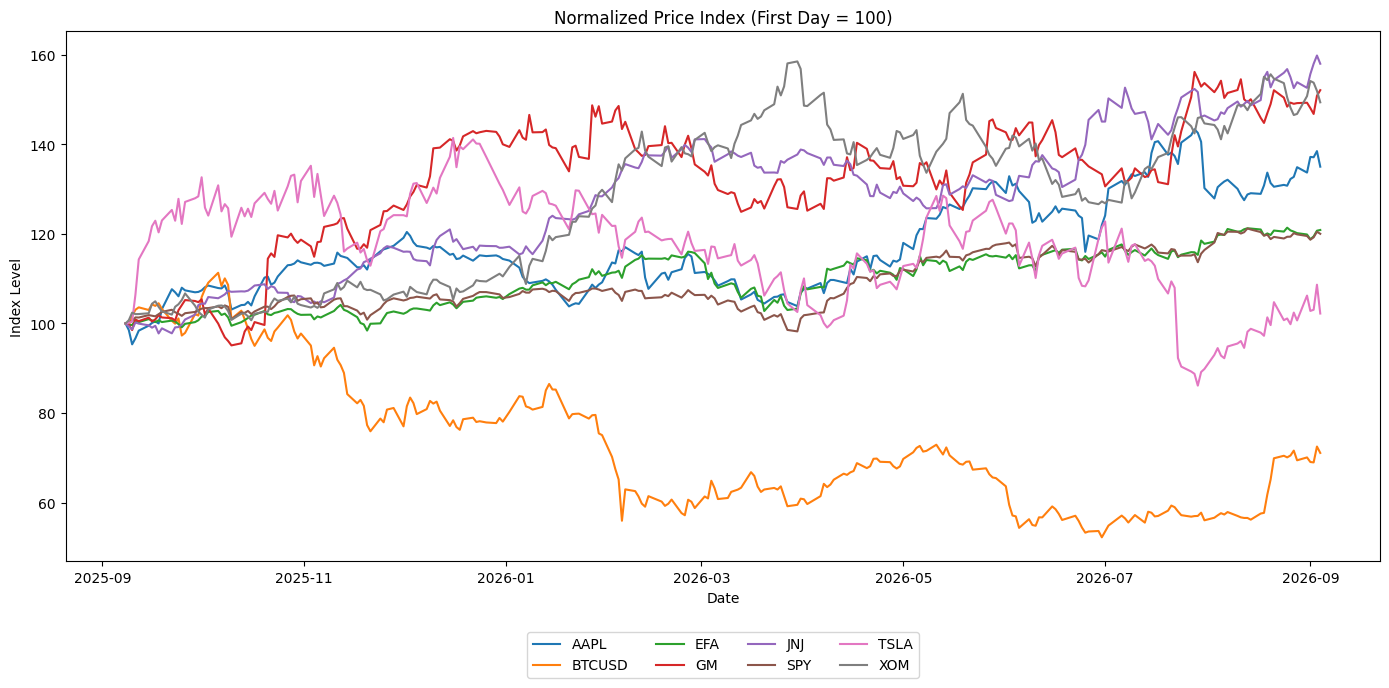

In [10]:
# Normalized to 100
normalized_df_close = df_close.div(df_close.iloc[0]).mul(100)

plt.figure(figsize=(14,7))
for c in normalized_df_close.columns:
    plt.plot(normalized_df_close.index, normalized_df_close[c], label=c)
plt.title('Normalized Price Index (First Day = 100)')
plt.xlabel('Date')
plt.ylabel('Index Level')
plt.legend(loc='upper center', bbox_to_anchor=(0.5,-0.12), ncol=4)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/normalized_prices.png', dpi=200, bbox_inches='tight')
plt.show()

In [15]:
pairs = []
for a,b in itertools.combinations(normalized_df_close.columns,2):
    mean_abs_gap = (normalized_df_close[a]-normalized_df_close[b]).abs().mean()
    pairs.append((a,b,mean_abs_gap))
closest_pair = min(pairs, key=lambda x:x[2])

final_norm = normalized_df_close.iloc[-1]
outperformers = final_norm[final_norm > final_norm['SPY']].sort_values(ascending=False)

# Find a 63-trading-day (~3 month) window ending when cross-sectional performance spread is greatest
spread = normalized_df_close.max(axis=1) - normalized_df_close.min(axis=1)
spread_end = spread.idxmax()
spread_start = normalized_df_close.index[max(0, normalized_df_close.index.get_loc(spread_end)-63)]
best_on_spread_end = normalized_df_close.loc[spread_end].idxmax()
worst_on_spread_end = normalized_df_close.loc[spread_end].idxmin()

print(f'The hardest pair to distinguish is {closest_pair[0]} and {closest_pair[1]}, with the smallest average normalized-index gap ({closest_pair[2]:.2f} points).\n')

print('Final normalized levels:')
display(final_norm.sort_values(ascending=False).round(2).to_frame('Final normalized index'))
print('Outperformed SPY:', list(outperformers.index))
print(f'Largest cross-sectional spread occurs around {spread_end.date()}; inspect roughly {spread_start.date()} to {spread_end.date()}.')
print(f'At the spread end, best = {best_on_spread_end}; worst = {worst_on_spread_end}; spread = {spread.loc[spread_end]:.2f} normalized points.')

The hardest pair to distinguish is EFA and SPY, with the smallest average normalized-index gap (2.33 points).

Final normalized levels:


,Final normalized index
Ticker,
JNJ,157.99
GM,152.09
XOM,149.38
AAPL,135.01
EFA,120.87
SPY,120.02
TSLA,102.22
BTCUSD,71.09


Outperformed SPY: ['JNJ', 'GM', 'XOM', 'AAPL', 'EFA']
Largest cross-sectional spread occurs around 2026-07-28; inspect roughly 2026-04-27 to 2026-07-28.
At the spread end, best = GM; worst = BTCUSD; spread = 99.18 normalized points.


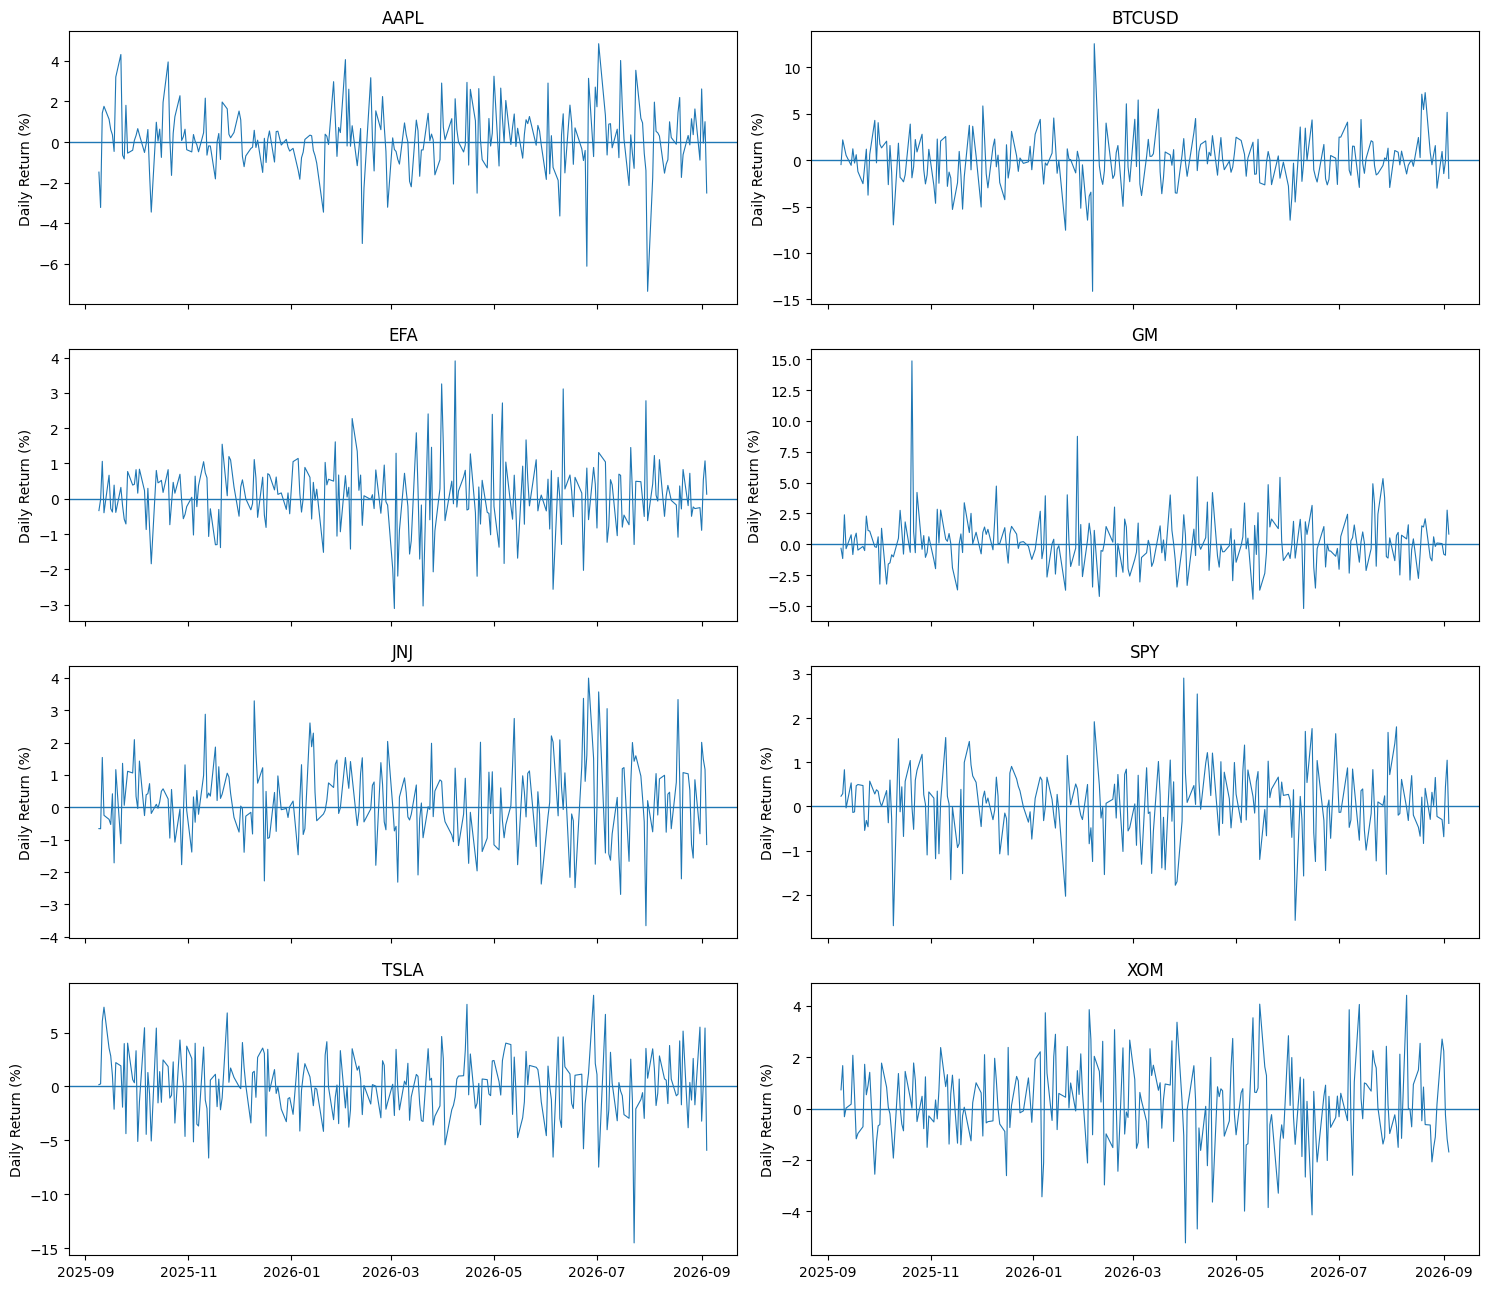

In [16]:
# Part B: Daily return subplots
returns_pct = daily_returns * 100

fig, axes = plt.subplots(4,2, figsize=(15,13), sharex=True)
axes = axes.ravel()
for ax,t in zip(axes, returns_pct.columns):
    ax.plot(returns_pct.index, returns_pct[t], linewidth=0.8)
    ax.axhline(0, linewidth=1)
    ax.set_title(t)
    ax.set_ylabel('Daily Return (%)')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/daily_return_subplots.png', dpi=200, bbox_inches='tight')
plt.show()

In [19]:
stacked_abs = returns_pct.abs().stack()
largest_idx = stacked_abs.idxmax()
largest_date, largest_ticker = largest_idx
largest_move = returns_pct.loc[largest_date, largest_ticker]

# Same-direction co-movement:
# Find date maximizing count of >2% positive moves or <-2% negative moves.
pos_count = (returns_pct > 2).sum(axis=1)
neg_count = (returns_pct < -2).sum(axis=1)
co_date = pd.concat([pos_count.rename('pos'),neg_count.rename('neg')],axis=1).max(axis=1).idxmax()
direction = 'positive' if pos_count.loc[co_date] >= neg_count.loc[co_date] else 'negative'
count_same = max(pos_count.loc[co_date], neg_count.loc[co_date])

print(f'Largest single daily move: {largest_ticker} on {largest_date.date()}, {largest_move:.2f}%.')
print(f'A strong same-direction co-movement date is {co_date.date()}: {count_same} assets had moves larger than 2% in the {direction} direction.')

Largest single daily move: GM on 2025-10-21, 14.86%.
A strong same-direction co-movement date is 2026-03-31: 6 assets had moves larger than 2% in the positive direction.


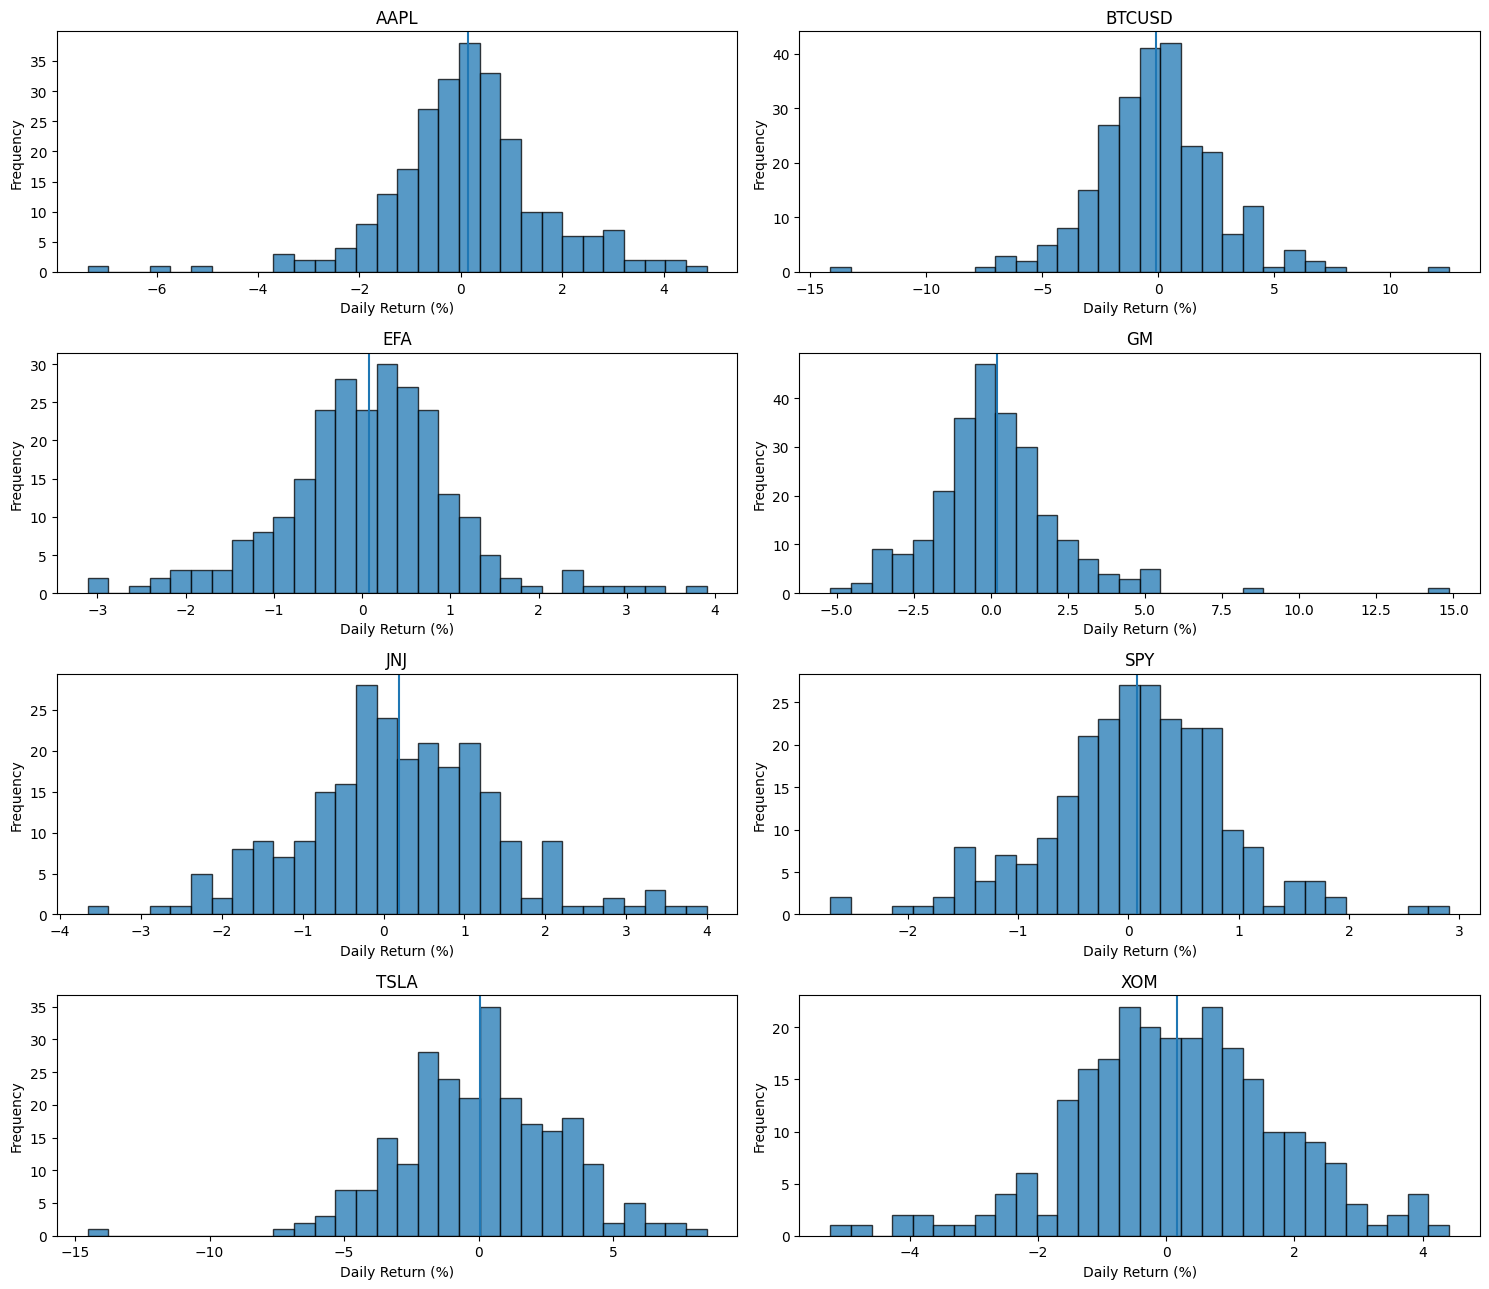

,Skewness,Excess Kurtosis,Shape,Normality score
Ticker,,,,
JNJ,0.130,0.594,roughly symmetric,0.724
XOM,-0.180,0.578,roughly symmetric,0.757
SPY,-0.209,1.198,heavy-tailed,1.407
EFA,0.136,1.867,heavy-tailed,2.002
TSLA,-0.325,1.740,heavy-tailed,2.065
AAPL,-0.449,3.045,heavy-tailed,3.493
BTCUSD,-0.051,3.860,heavy-tailed,3.911
GM,1.608,8.866,heavy-tailed,10.475


Most normal-looking to least (using |skew| + |excess kurtosis|):
JNJ > XOM > SPY > EFA > TSLA > AAPL > BTCUSD > GM
Most heavy-tailed by excess kurtosis: GM, excess kurtosis = 8.87.


In [21]:
# Part C: Histograms
fig, axes = plt.subplots(4,2, figsize=(15,13))
axes = axes.ravel()
for ax,t in zip(axes, returns_pct.columns):
    ax.hist(returns_pct[t].dropna(), bins=30, edgecolor='black', alpha=0.75)
    ax.axvline(returns_pct[t].mean(), linewidth=1.5)
    ax.set_title(t)
    ax.set_xlabel('Daily Return (%)')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/return_histograms.png', dpi=200, bbox_inches='tight')
plt.show()

# Shape metrics
skewness = daily_returns.skew()
excess_kurt = daily_returns.kurt()  # pandas returns excess kurtosis

shape_table = pd.DataFrame({
    'Skewness': skewness,
    'Excess Kurtosis': excess_kurt
})

def shape_label(sk, ku):
    if ku > 1:
        base = 'heavy-tailed'
    elif sk > 0.5:
        base = 'right-skewed'
    elif sk < -0.5:
        base = 'left-skewed'
    else:
        base = 'roughly symmetric'
    return base

shape_table['Shape'] = [shape_label(shape_table.loc[t,'Skewness'], shape_table.loc[t,'Excess Kurtosis']) for t in shape_table.index]
shape_table['Normality score'] = shape_table['Skewness'].abs() + shape_table['Excess Kurtosis'].abs()
shape_table = shape_table.sort_values('Normality score')

display(shape_table.round(3))

most_heavy = excess_kurt.idxmax()

print('Most normal-looking to least (using |skew| + |excess kurtosis|):')
print(' > '.join(shape_table.index))
print(f'Most heavy-tailed by excess kurtosis: {most_heavy}, excess kurtosis = {excess_kurt[most_heavy]:.2f}.')

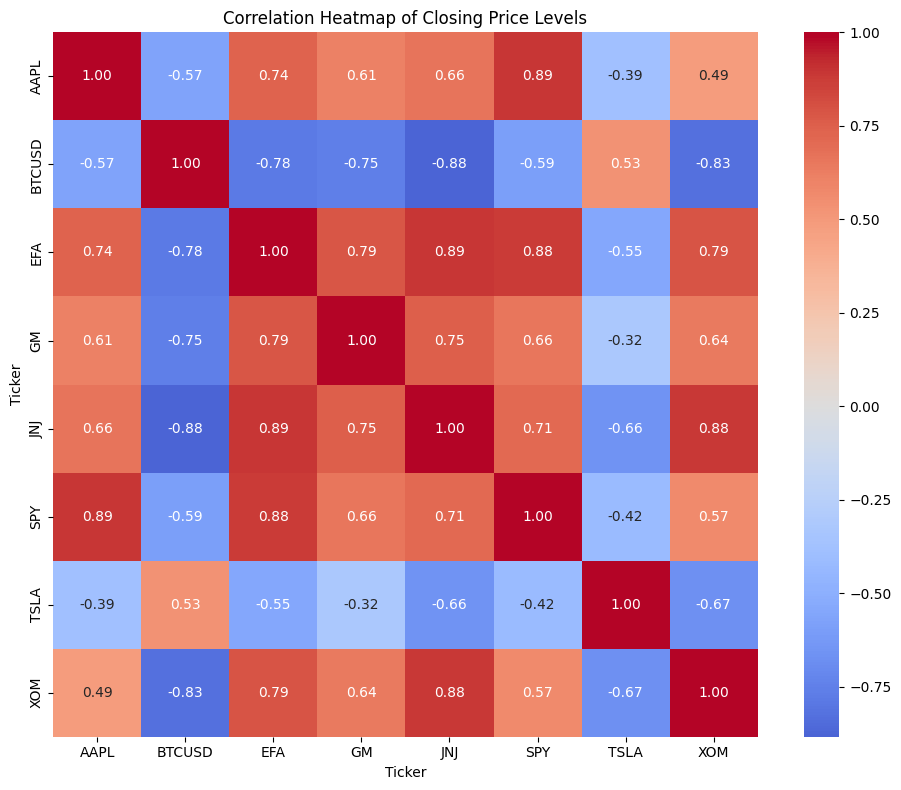

Strongest 3-asset cluster by average price-level correlation: ('EFA', 'JNJ', 'XOM'), mean pairwise correlation = 0.85.
Most independent by lowest average correlation with the rest: BTCUSD, average correlation = -0.55.


In [22]:
# Part D: Required PRICE-LEVEL correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df_close.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap of Closing Price Levels')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/price_correlation_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

avg_corr = df_close.corr().apply(lambda s: (s.sum()-1)/(len(s)-1))
most_independent = avg_corr.idxmin()

# strongest 3-asset cluster: maximize mean pairwise corr
best_cluster = None
best_cluster_corr = -999
for combo in itertools.combinations(df_close.columns,3):
    sub = df_close[list(combo)].corr()
    vals = [sub.iloc[0,1], sub.iloc[0,2], sub.iloc[1,2]]
    m = np.mean(vals)
    if m > best_cluster_corr:
        best_cluster_corr = m
        best_cluster = combo

print(f'Strongest 3-asset cluster by average price-level correlation: {best_cluster}, mean pairwise correlation = {best_cluster_corr:.2f}.')
print(f'Most independent by lowest average correlation with the rest: {most_independent}, average correlation = {avg_corr[most_independent]:.2f}.')

In [24]:
# Section 4 — Portfolio Construction

# Client: David, age 61, retirement in 6 years, $40,000 investable, maximum tolerable one-year loss 25%, wants returns meaningfully above 4.5% with limited downside.
# The allocation below deliberately emphasizes diversified/defensive assets and assigns 0% to the most speculative positions.

allocation = pd.Series({
    'SPY': 45,
    'TSLA': 0,
    'GM': 0,
    'BTCUSD': 0,
    'AAPL': 5,
    'JNJ': 20,
    'XOM': 15,
    'EFA': 15
}, dtype=float)
assert abs(allocation.sum()-100) < 1e-9
display(allocation.to_frame('Allocation %'))
dollars = allocation/100 * 40000
display(dollars.to_frame('Dollar Allocation'))

print('SPY 45%, AAPL 5%, JNJ 20%, XOM 15%, EFA 15%, TSLA 0%, GM 0%, BTCUSD 0%.')
print('The portfolio emphasizes broad-market and defensive diversification. TSLA and BTCUSD are excluded because the client explicitly rejects speculative positions; '
      'GM is excluded to avoid adding another concentrated cyclical auto position when SPY already contains diversified U.S. equity exposure.')

,Allocation %
SPY,45.0
TSLA,0.0
GM,0.0
BTCUSD,0.0
AAPL,5.0
JNJ,20.0
XOM,15.0
EFA,15.0


,Dollar Allocation
SPY,18000.0
TSLA,0.0
GM,0.0
BTCUSD,0.0
AAPL,2000.0
JNJ,8000.0
XOM,6000.0
EFA,6000.0


SPY 45%, AAPL 5%, JNJ 20%, XOM 15%, EFA 15%, TSLA 0%, GM 0%, BTCUSD 0%.
The portfolio emphasizes broad-market and defensive diversification. TSLA and BTCUSD are excluded because the client explicitly rejects speculative positions; GM is excluded to avoid adding another concentrated cyclical auto position when SPY already contains diversified U.S. equity exposure.


In [25]:
print('QUANTITATIVE ANCHORS')
for t,w in allocation[allocation>0].items():
    print(f'{t} ({w:.0f}%): annual return {annual_return_pct[t]:.2f}%, Sharpe {sharpe[t]:.3f}, '
          f'annualized return volatility {ann_vol[t]*100:.2f}%, avg return correlation with others '
          f'{((return_corr.loc[t].sum()-1)/(len(return_corr)-1)):.2f}.')

QUANTITATIVE ANCHORS
SPY (45%): annual return 20.02%, Sharpe 1.147, annualized return volatility 12.83%, avg return correlation with others 0.32.
AAPL (5%): annual return 35.01%, Sharpe 1.152, annualized return volatility 25.12%, avg return correlation with others 0.16.
JNJ (20%): annual return 57.99%, Sharpe 2.277, annualized return volatility 19.08%, avg return correlation with others -0.03.
XOM (15%): annual return 49.38%, Sharpe 1.529, annualized return volatility 25.69%, avg return correlation with others -0.13.
EFA (15%): annual return 20.87%, Sharpe 1.010, annualized return volatility 15.67%, avg return correlation with others 0.30.


In [27]:
# This allocation is 100% in equity/ETF positions, so portfolio falls approximately 20%.
initial_value = 40000
stress_loss_pct = 0.20
stress_value = initial_value * (1-stress_loss_pct)
stress_loss_dollars = initial_value - stress_value

print(f'Initial portfolio = ${initial_value:,.2f}')
print(f'20% stress loss = ${initial_value:,.2f} × 0.20 = ${stress_loss_dollars:,.2f}')
print(f'Ending value = ${initial_value:,.2f} − ${stress_loss_dollars:,.2f} = ${stress_value:,.2f}')
print(f'Loss percentage = 20.00%, which is below David\'s 25% maximum.')

Initial portfolio = $40,000.00
20% stress loss = $40,000.00 × 0.20 = $8,000.00
Ending value = $40,000.00 − $8,000.00 = $32,000.00
Loss percentage = 20.00%, which is below David's 25% maximum.


ADDITIONAL ANALYSIS 1 — MAXIMUM DRAWDOWN


,Max Drawdown %
Ticker,
BTCUSD,-53.06
TSLA,-39.10
XOM,-20.11
GM,-16.00
AAPL,-13.80
EFA,-11.42
JNJ,-10.96
SPY,-8.88


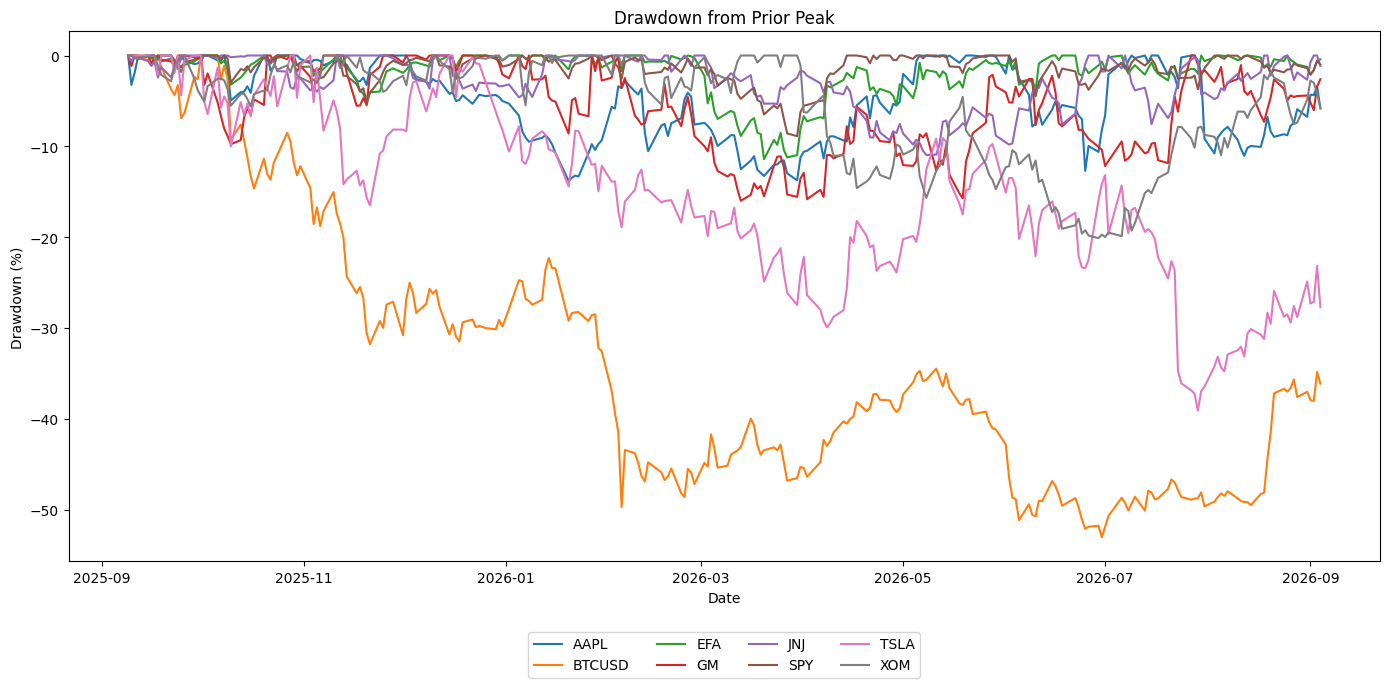

In [28]:
# Section 5 — Additional Analysis
# Additional Analysis 1: Maximum drawdown
wealth_index = (1 + daily_returns).cumprod()
running_peak = wealth_index.cummax()
drawdown = wealth_index / running_peak - 1
max_drawdown = drawdown.min().sort_values()

print('ADDITIONAL ANALYSIS 1 — MAXIMUM DRAWDOWN')
display((max_drawdown*100).round(2).to_frame('Max Drawdown %'))

plt.figure(figsize=(14,7))
for t in drawdown.columns:
    plt.plot(drawdown.index, drawdown[t]*100, label=t)
plt.title('Drawdown from Prior Peak')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.legend(loc='upper center', bbox_to_anchor=(0.5,-0.12), ncol=4)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/max_drawdown.png', dpi=200, bbox_inches='tight')
plt.show()

ADDITIONAL ANALYSIS 2 — DOWNSIDE RISK AND SORTINO RATIO


,Annual Return %,Annualized Volatility %,Downside Deviation %,Sharpe Ratio,Sortino Ratio
Ticker,,,,,
JNJ,57.99,19.083,10.170,2.277,4.273
XOM,49.38,25.691,14.676,1.529,2.676
GM,52.09,34.194,16.392,1.272,2.653
SPY,20.02,12.833,7.734,1.147,1.904
AAPL,35.01,25.122,15.333,1.152,1.887
EFA,20.87,15.672,9.053,1.010,1.749
TSLA,2.22,47.470,28.699,0.190,0.314
BTCUSD,-28.91,43.962,26.889,-0.664,-1.086


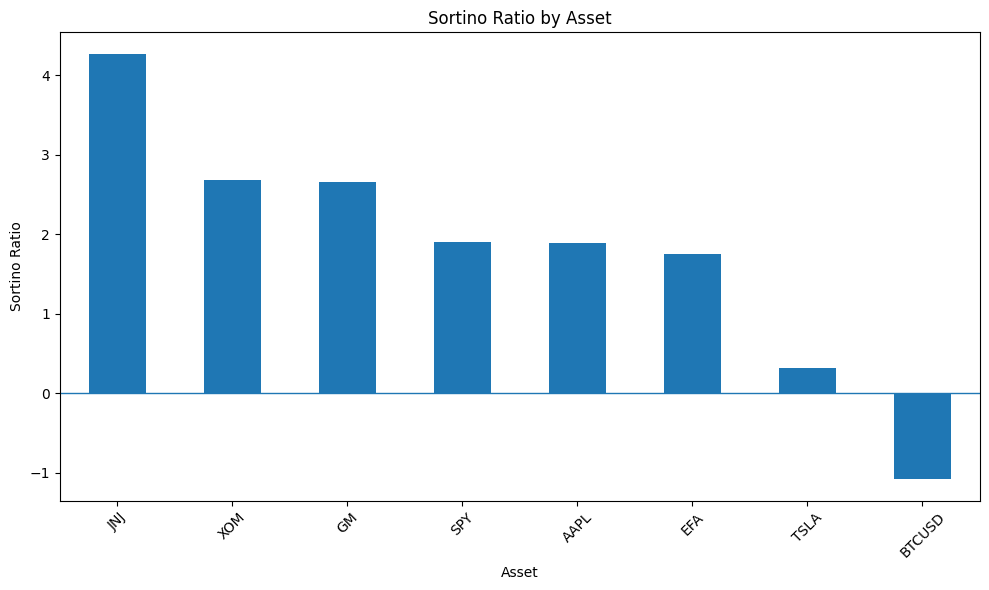

Highest Sortino Ratio: JNJ (4.273)
Lowest Sortino Ratio: BTCUSD (-1.086)

Downside deviation ranking:


,Annualized Downside Deviation %
Ticker,
SPY,7.73
EFA,9.05
JNJ,10.17
XOM,14.68
AAPL,15.33
GM,16.39
BTCUSD,26.89
TSLA,28.70


In [29]:
# Additional Analysis 2: Sortino Ratio and Downside Risk

# Daily risk-free rate specified in the assignment
rf_daily = 0.045 / 252

# Downside returns: only observations below the daily risk-free rate
downside_returns = daily_returns - rf_daily
downside_returns = downside_returns.where(downside_returns < 0, 0)

# Annualized downside deviation
downside_deviation = downside_returns.std() * np.sqrt(252)

# Annualized excess return
annualized_excess_return = (daily_returns.mean() - rf_daily) * 252

# Sortino Ratio
sortino_ratio = annualized_excess_return / downside_deviation

# Create summary table
sortino_table = pd.DataFrame({
    'Annual Return %': annual_return_pct,
    'Annualized Volatility %': ann_vol * 100,
    'Downside Deviation %': downside_deviation * 100,
    'Sharpe Ratio': sharpe,
    'Sortino Ratio': sortino_ratio
})

sortino_table = sortino_table.sort_values(
    'Sortino Ratio',
    ascending=False
).round(3)

print("ADDITIONAL ANALYSIS 2 — DOWNSIDE RISK AND SORTINO RATIO")
display(sortino_table)

# Bar chart of Sortino ratios
plt.figure(figsize=(10,6))

sortino_ratio.sort_values(ascending=False).plot(
    kind='bar'
)

plt.axhline(0, linewidth=1)
plt.title('Sortino Ratio by Asset')
plt.xlabel('Asset')
plt.ylabel('Sortino Ratio')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    f'{RESULTS_DIR}/sortino_ratio.png',
    dpi=200,
    bbox_inches='tight'
)

plt.show()

# Automatically identify best and worst
best_sortino = sortino_ratio.idxmax()
worst_sortino = sortino_ratio.idxmin()

print(
    f'Highest Sortino Ratio: {best_sortino} '
    f'({sortino_ratio[best_sortino]:.3f})'
)

print(
    f'Lowest Sortino Ratio: {worst_sortino} '
    f'({sortino_ratio[worst_sortino]:.3f})'
)

print("\nDownside deviation ranking:")
display(
    (downside_deviation * 100)
    .sort_values()
    .round(2)
    .to_frame('Annualized Downside Deviation %')
)